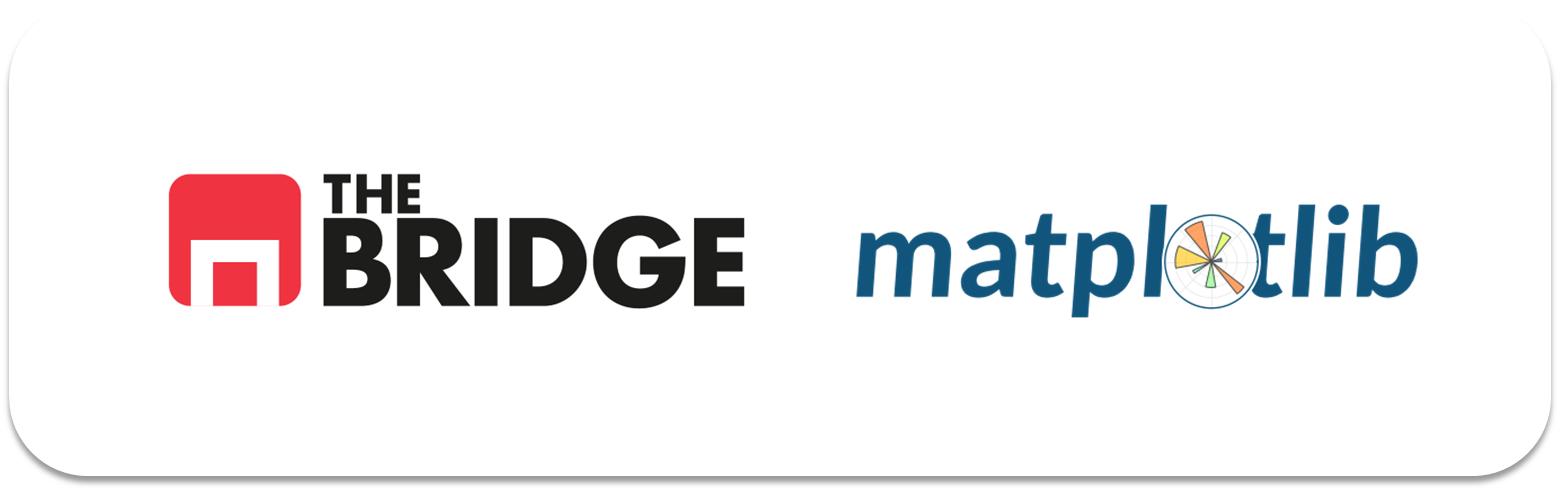

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv("./data/california_cities.csv")
df.head(10)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
7,7,AmadorCity,38.419444,-120.824167,280.0,919.0,185,0.314,0.314,0.000,0.813,0.813,0.000,0.00
8,8,AmericanCanyon,38.168056,-122.252500,14.0,46.0,19454,4.845,4.837,0.008,12.548,12.527,0.021,0.17
9,9,Anaheim,33.836111,-117.889722,48.0,157.0,336000,50.811,49.835,0.976,131.600,129.073,2.527,1.92


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


Primero voy a tratar los nulos de elevation_m y elevation_ft, haciendo la conversión de metros a pies y viceversa en todos los casos que es posible (aquellos donde una de las variables no sea nula).

In [4]:
print(df["elevation_m"].isnull().sum())
print(df["elevation_ft"].isnull().sum())

48
12


In [5]:
mascara = df["elevation_m"].isnull() & df["elevation_ft"].notnull()
df.loc[mascara, "elevation_m"] = df.loc[mascara, "elevation_ft"]* 0.3048

In [6]:
print(df["elevation_m"].isnull().sum())

8


In [7]:
mascara = df["elevation_ft"].isnull() & df["elevation_m"].notnull()
df.loc[mascara, "elevation_ft"] = df.loc[mascara, "elevation_m"] / 0.3048

In [8]:
print(df["elevation_m"].isnull().sum())
print(df["elevation_ft"].isnull().sum())

8
8


Con esta conversión al final solo quedan 8 nulos en ambas variables que voy a rellenar con la mediana

In [9]:
df["elevation_m"] = df["elevation_m"].fillna(df["elevation_m"].median())
df["elevation_ft"] = df["elevation_ft"].fillna(df["elevation_ft"].median())
#df.dropna(subset=["elevation_m", "elevation_ft"], inplace=True)
print(df["elevation_m"].isnull().sum())
print(df["elevation_ft"].isnull().sum())

0
0


Ahora voy a hacer la conversion para la variables de area(area_total, area_water y area_land)

In [10]:
print(df["area_total_sq_mi"].isnull().sum())
print(df["area_total_km2"].isnull().sum())
print(df["area_water_sq_mi"].isnull().sum())
print(df["area_water_km2"].isnull().sum())
print(df["area_land_sq_mi"].isnull().sum())
print(df["area_land_km2"].isnull().sum())

2
5
1
4
0
4


In [11]:
FACTOR = 2.58999 # 1 milla = 2.58999 km

for sq_col, km_col in [("area_total_sq_mi", "area_total_km2"),
                       ("area_water_sq_mi", "area_water_km2"),
                       ("area_land_sq_mi", "area_land_km2")]:
    mascara = df[km_col].isnull() & df[sq_col].notnull()
    df.loc[mascara, km_col] = df.loc[mascara, sq_col] * FACTOR

    mascara = df[sq_col].isnull() & df[km_col].notnull()
    df.loc[mascara, sq_col] = df.loc[mascara, km_col] / FACTOR


In [12]:
print(df["area_total_sq_mi"].isnull().sum())
print(df["area_total_km2"].isnull().sum())
print(df["area_water_sq_mi"].isnull().sum())
print(df["area_water_km2"].isnull().sum())
print(df["area_land_sq_mi"].isnull().sum())
print(df["area_land_km2"].isnull().sum())

1
1
0
0
0
0


Nos queda un nulo de area total que lo vamos a rellenar con la suma de los valores de area_land y area_water

In [13]:
mascara = (df["area_total_sq_mi"].isnull() & 
        df["area_land_sq_mi"].notnull() & 
        df["area_water_sq_mi"].notnull())
df.loc[mascara, "area_total_sq_mi"] = df.loc[mascara, "area_land_sq_mi"] + df.loc[mascara, "area_water_sq_mi"]
df.loc[mascara, "area_total_km2"]   = df.loc[mascara, "area_total_sq_mi"] * FACTOR

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         482 non-null    float64
 5   elevation_ft        482 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    482 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    482 non-null    float64
 10  area_total_km2      482 non-null    float64
 11  area_land_km2       482 non-null    float64
 12  area_water_km2      482 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


Solo nos quedan 5 nulos en area_water_percent que podemos calcular con los otros valores perfectamente.

In [15]:
mascara = (df["area_water_percent"].isnull() & 
           df["area_water_sq_mi"].notnull() & 
           df["area_total_sq_mi"].notnull())
df.loc[mascara, "area_water_percent"] = (df.loc[mascara, "area_water_sq_mi"] / df.loc[mascara, "area_total_sq_mi"]) * 100

In [16]:
print(df.isnull().sum())

Unnamed: 0            0
city                  0
latd                  0
longd                 0
elevation_m           0
elevation_ft          0
population_total      0
area_total_sq_mi      0
area_land_sq_mi       0
area_water_sq_mi      0
area_total_km2        0
area_land_km2         0
area_water_km2        0
area_water_percent    0
dtype: int64


Ya nos hemos quedado sin nulos.

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

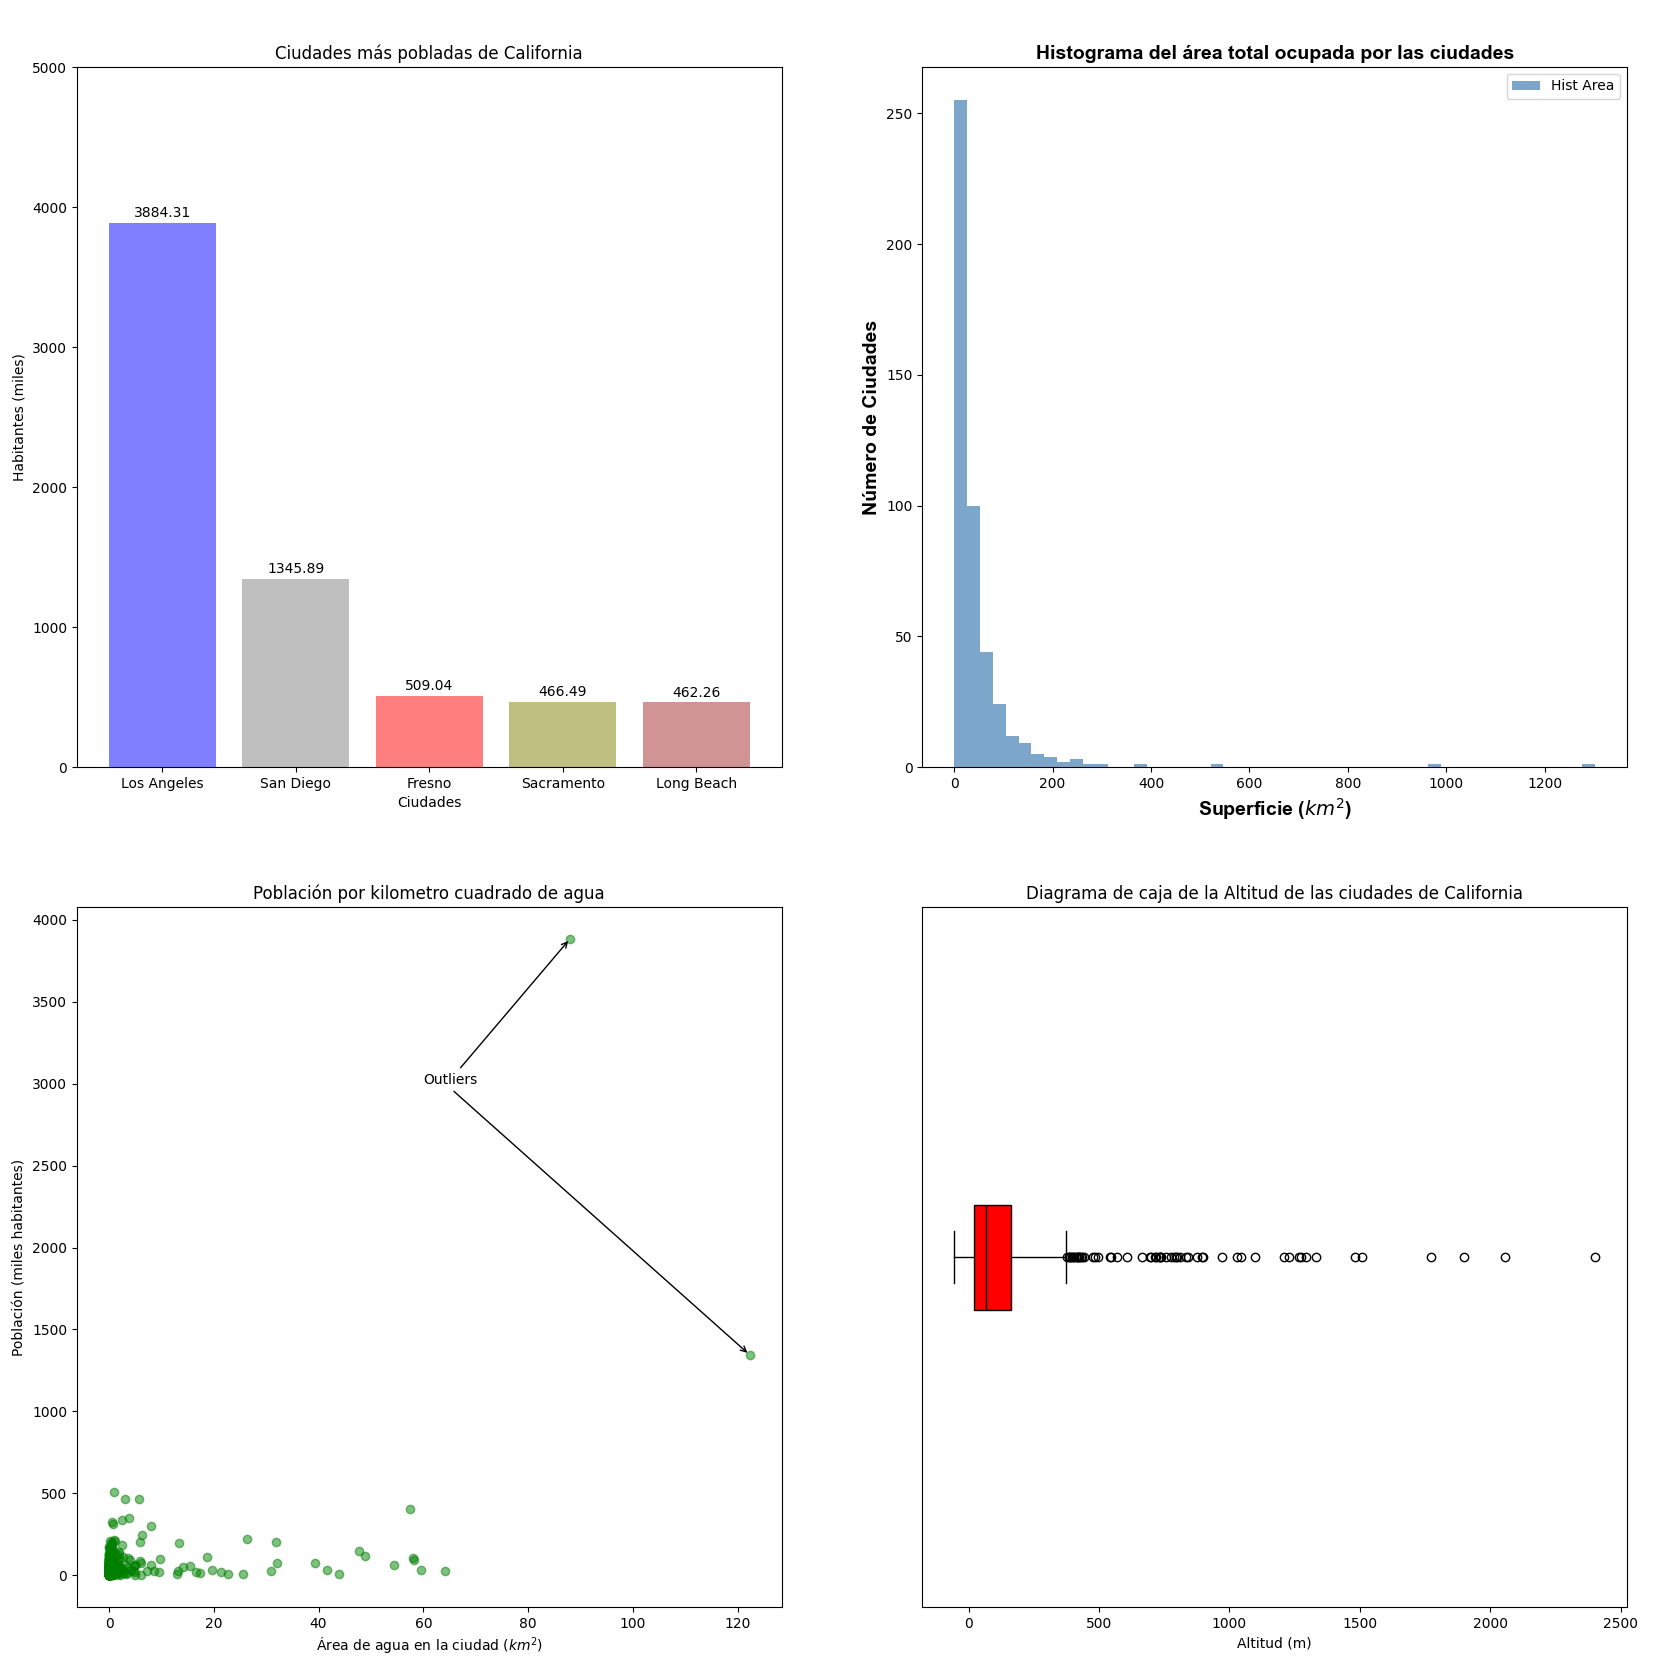

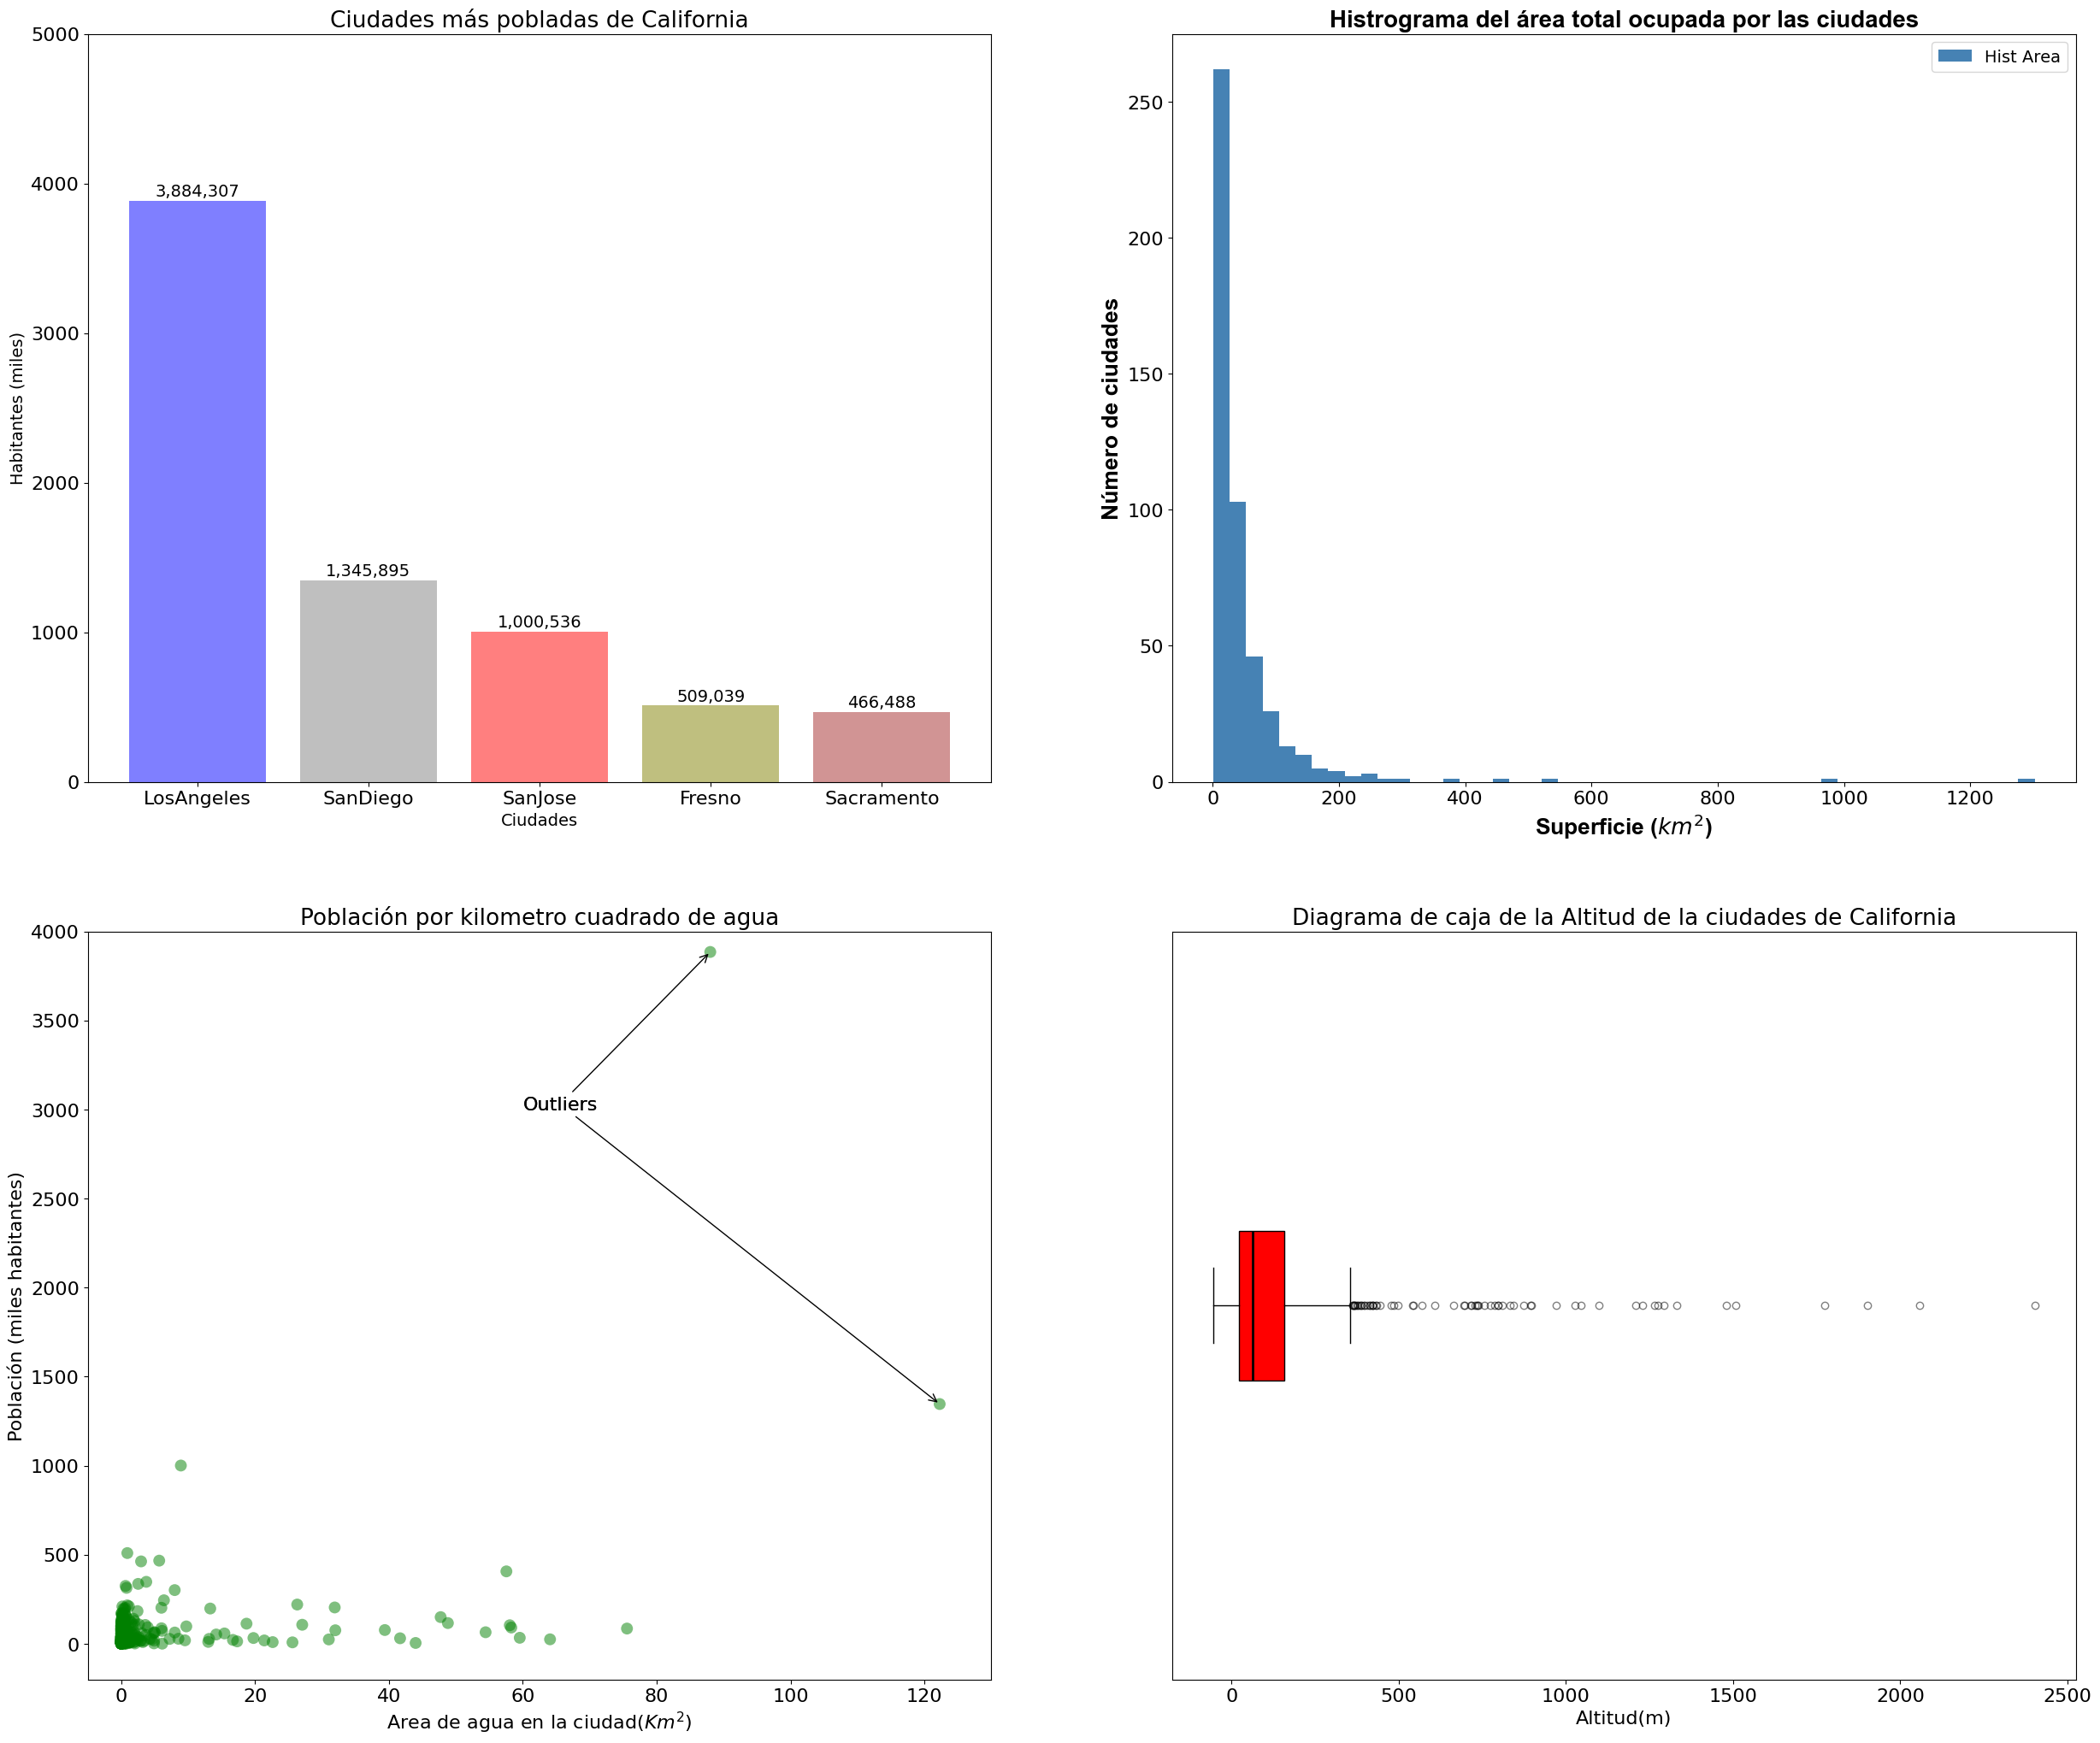

In [53]:
san_francisco = df[df["city"] == "SanFrancisco"].index    # Como con el tratamiento de nulos que hice no borré ninguna fila
df.drop(san_francisco, inplace=True)                       # voy a eliminatr San Francisco para que las gráficas sean iguales

top_5 = df.nlargest(5, "population_total")[["city", "population_total"]].reset_index(drop=True)
color_bar = ["blue", "gray", "red", "olive", "brown"] 

fig,ax = plt.subplots(2,2,figsize = (30,25))
fig.subplots_adjust(wspace= 0.2)

# GRAFICO CIUDADES MÁS POBLADAS

bars = ax[0,0].bar(top_5["city"], top_5["population_total"] / 1000, color= color_bar, alpha = 0.5)
ax[0,0].set_title("Ciudades más pobladas de California", fontsize=19)
ax[0,0].set_xlabel("Ciudades", fontsize=14)
ax[0,0].set_ylabel("Habitantes (miles)", fontsize=14)
ax[0,0].set_yticks([0, 1000, 2000, 3000, 4000, 5000])
ax[0,0].tick_params(axis="both", labelsize=16)

for bar, val in zip(bars, top_5["population_total"]):
    ax[0,0].text(bar.get_x() + bar.get_width() / 2,  # centro de la barra en x
    bar.get_height() + 10,                           # justo encima de la barra
    f"{val:,.0f}",                                   # formato del número
    ha="center", va="bottom", fontsize=14)

# GRÁFICO HISTOGRAMA AREA TOTAL

ax[0,1].hist(df["area_total_km2"], bins=50, color="steelblue", label="Hist Area");
ax[0,1].set_title("Histrograma del área total ocupada por las ciudades",
              fontname="Arial", fontsize=20, fontweight="bold")
ax[0,1].set_xlabel("Superficie ($km^2$)",fontname="Arial", fontsize=19, fontweight="bold")
ax[0,1].set_ylabel("Número de ciudades",fontname="Arial", fontsize=19, fontweight="bold")
ax[0,1].legend(fontsize=14, loc="upper right")
ax[0,1].tick_params(axis="both", labelsize=16)


# DIAGRAMA DE DISPERSION  ÁREA DE AGUA VS POBLACIÓN



ax[1,0].scatter(df["area_water_km2"], df["population_total"] / 1000, alpha=0.5, color="green", edgecolors="none", s=100)
ax[1,0].set_title("Población por kilometro cuadrado de agua", fontsize=19)
ax[1,0].set_xlabel("Area de agua en la ciudad($Km^2$)", fontsize=16)
ax[1,0].set_ylabel("Población (miles habitantes)", fontsize=16)
ax[1,0].set_xlim(-5, 130)
ax[1,0].set_ylim(-200, 4000)
ax[1,0].set_xticks([0, 20, 40, 60, 80, 100, 120])
ax[1,0].set_yticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000])
ax[1,0].tick_params(axis="both", labelsize=16)

outlier_pobl = df.nlargest(1, "population_total") # el de mayor población
outlier_agua = df.nlargest(1, "area_water_km2")   # el de mayor area de agua
texto_pos = (60,3000)
dict_f = {"arrowstyle":"->", "color":"black"}

ax[1,0].annotate("Outliers",
                 xy=(outlier_pobl["area_water_km2"].values[0], outlier_pobl["population_total"].values[0] / 1000),
                 xytext=texto_pos,
                 fontsize=16,
                 arrowprops=dict_f
)

ax[1,0].annotate("Outliers",
                 xy=(outlier_agua["area_water_km2"].values[0], outlier_agua["population_total"].values[0] / 1000),
                 xytext=texto_pos,
                 fontsize=16,
                 arrowprops=dict_f
)

# GRÁFICO CON DIAGRAMA DE CAJAS DE LA ALTITUD DE LAS CIUDADES

ax[1,1].boxplot(df["elevation_m"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="red", color="black"),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(color="black"),
            widths=0.2,
            capprops=dict(color="black"),
            flierprops=dict(marker="o", color="black", alpha=0.5))
ax[1,1].set_title("Diagrama de caja de la Altitud de la ciudades de California", fontsize=19)
ax[1,1].set_xlabel("Altitud(m)", fontsize=16)
ax[1,1].set_yticks([])
ax[1,1].tick_params(axis="both", labelsize=16)

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.